<a href="https://colab.research.google.com/github/MahendraVarma17/internship_projects/blob/main/ml_model_trainings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/task8 dataset.csv")

df.head()


,Student_ID,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Final_Completion_Status
0,1.0,100.0,37.0,79.0,6.0,6.4,58.0,Completed
1,2.0,66.0,68.0,47.0,25.0,4.3,54.0,Not Completed
2,3.0,47.0,59.0,47.0,17.0,2.0,57.0,Not Completed
3,4.0,77.0,35.0,86.0,19.0,3.3,19.0,Completed
4,5.0,62.0,55.0,35.0,29.0,1.5,124.0,Not Completed


In [ ]:
df.shape

(101, 8)

In [ ]:
df.columns

Index(['Student_ID', 'Attendance_Percentage', 'Assessment_Score',
       'Assignment_Completion_Rate', 'Login_Frequency', 'Study_Hours',
       'Activity_Count', 'Final_Completion_Status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  100 non-null    float64
 1   Attendance_Percentage       100 non-null    float64
 2   Assessment_Score            100 non-null    float64
 3   Assignment_Completion_Rate  100 non-null    float64
 4   Login_Frequency             100 non-null    float64
 5   Study_Hours                 100 non-null    float64
 6   Activity_Count              100 non-null    float64
 7   Final_Completion_Status     100 non-null    object 
dtypes: float64(7), object(1)
memory usage: 6.4+ KB


In [ ]:
df.isnull().sum()

,0
Student_ID,1
Attendance_Percentage,1
Assessment_Score,1
Assignment_Completion_Rate,1
Login_Frequency,1
Study_Hours,1
Activity_Count,1
Final_Completion_Status,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Final_Completion_Status"] = df["Final_Completion_Status"].map({
    "Completed": 1,
    "Not Completed": 0
})

In [ ]:
df.head()

,Student_ID,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Final_Completion_Status
0,1.0,100.0,37.0,79.0,6.0,6.4,58.0,1.0
1,2.0,66.0,68.0,47.0,25.0,4.3,54.0,0.0
2,3.0,47.0,59.0,47.0,17.0,2.0,57.0,0.0
3,4.0,77.0,35.0,86.0,19.0,3.3,19.0,1.0
4,5.0,62.0,55.0,35.0,29.0,1.5,124.0,0.0


In [ ]:
df["Final_Completion_Status"].value_counts()

,count
Final_Completion_Status,
1.0,50
0.0,50


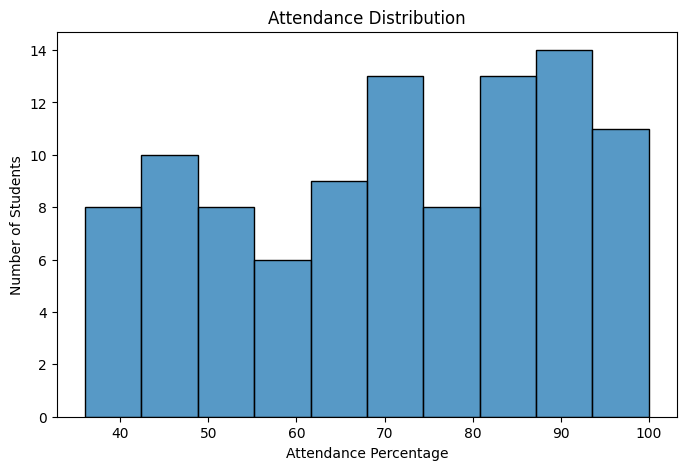

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Attendance_Percentage"], bins=10)
plt.title("Attendance Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")

plt.show()

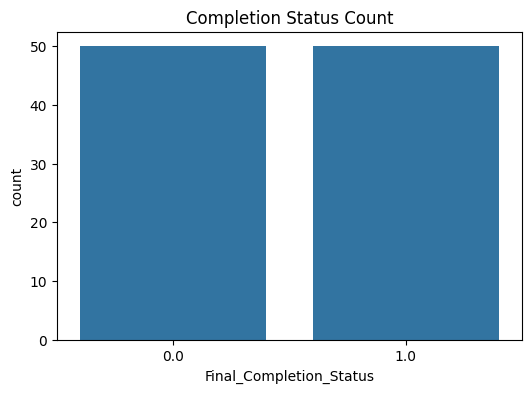

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Final_Completion_Status", data=df)
plt.title("Completion Status Count")
plt.show()

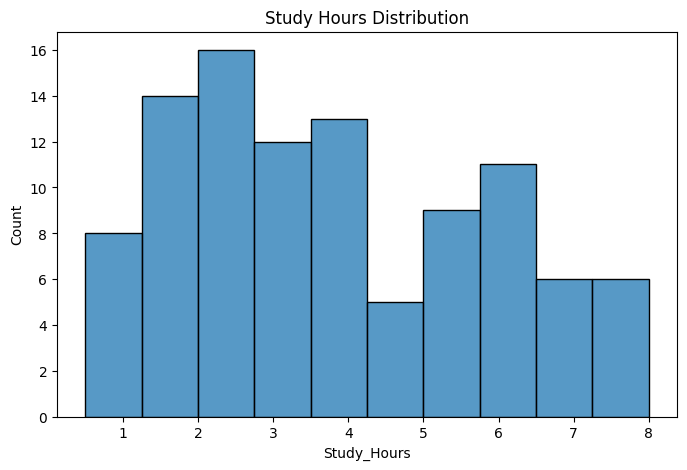

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Study_Hours"], bins=10)
plt.title("Study Hours Distribution")
plt.show()

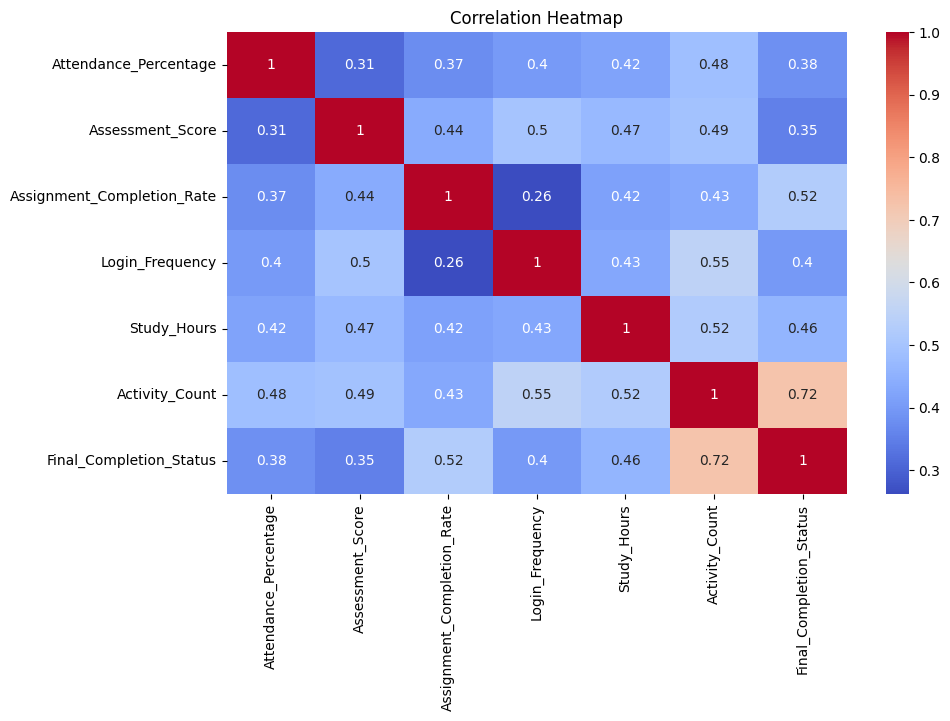

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.drop("Student_ID", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.corr()

,Student_ID,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Final_Completion_Status
Student_ID,1.000000,0.045350,0.188206,0.163627,-0.080315,-0.143975,0.062306,0.143421
Attendance_Percentage,0.045350,1.000000,0.311355,0.374667,0.401028,0.417790,0.484120,0.380372
Assessment_Score,0.188206,0.311355,1.000000,0.437434,0.498610,0.469737,0.494185,0.353239
Assignment_Completion_Rate,0.163627,0.374667,0.437434,1.000000,0.261701,0.415276,0.430785,0.524835
Login_Frequency,-0.080315,0.401028,0.498610,0.261701,1.000000,0.426744,0.552349,0.399281
Study_Hours,-0.143975,0.417790,0.469737,0.415276,0.426744,1.000000,0.522516,0.459616
Activity_Count,0.062306,0.484120,0.494185,0.430785,0.552349,0.522516,1.000000,0.723368
Final_Completion_Status,0.143421,0.380372,0.353239,0.524835,0.399281,0.459616,0.723368,1.000000


In [ ]:
X = df.drop(
    ["Student_ID", "Final_Completion_Status"],
    axis=1
)
y = df["Final_Completion_Status"]
print(X.head())
print(y.head())

   Attendance_Percentage  Assessment_Score  Assignment_Completion_Rate  \
0                  100.0              37.0                        79.0   
1                   66.0              68.0                        47.0   
2                   47.0              59.0                        47.0   
3                   77.0              35.0                        86.0   
4                   62.0              55.0                        35.0   

   Login_Frequency  Study_Hours  Activity_Count  
0              6.0          6.4            58.0  
1             25.0          4.3            54.0  
2             17.0          2.0            57.0  
3             19.0          3.3            19.0  
4             29.0          1.5           124.0  
0    1.0
1    0.0
2    0.0
3    1.0
4    0.0
Name: Final_Completion_Status, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (80, 6)
Testing Data: (21, 6)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])

[[-1.29226525 -1.01334902 -1.07086984 -1.22262744 -1.25599702 -1.31446141]
 [ 1.2531888  -0.11385944 -0.26154052 -0.40901375 -1.60856878 -1.38609336]
 [ 0.60328564 -0.86343409 -0.69000898  1.33444414 -0.24864916  0.61960126]
 [-0.91315508 -0.61357587 -0.69000898 -1.10639691 -1.05452745 -0.95630165]
 [ 0.38665125 -0.26377437  0.30975076 -0.87393586 -0.7019557  -0.95630165]]


In [ ]:
nan_rows_X = np.isnan(X_train_scaled).any(axis=1)
nan_rows_y = y_train.isna()
combined_nan_rows = nan_rows_X | nan_rows_y.values

X_train_scaled_cleaned = X_train_scaled[~combined_nan_rows]
y_train_cleaned = y_train[~combined_nan_rows]

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled_cleaned, y_train_cleaned)

LogisticRegression()

In [ ]:
lr_pred = lr_model.predict(X_test_scaled)
lr_pred

array([0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 0.,
       1., 1., 1., 1.])

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Accuracy: 0.8095238095238095
Precision: 0.8461538461538461
Recall: 0.8461538461538461
F1 Score: 0.8461538461538461


In [ ]:
cm = confusion_matrix(y_test, lr_pred)
print(cm)

[[ 6  2]
 [ 2 11]]


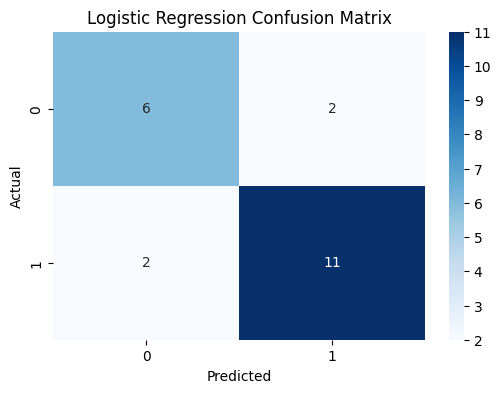

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)
# Clean X_train and y_train using the combined_nan_rows mask
X_train_cleaned_dt = X_train[~combined_nan_rows]
y_train_cleaned_dt = y_train[~combined_nan_rows]
dt_model.fit(X_train_cleaned_dt, y_train_cleaned_dt)
dt_pred = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_precision = precision_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score( y_test,dt_pred)
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1:", dt_f1)

Accuracy: 0.8095238095238095
Precision: 0.8
Recall: 0.9230769230769231
F1: 0.8571428571428571


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Clean X_train and y_train using the combined_nan_rows mask
X_train_cleaned_rf = X_train[~combined_nan_rows]
y_train_cleaned_rf = y_train[~combined_nan_rows]
rf_model.fit(X_train_cleaned_rf, y_train_cleaned_rf)
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score( y_test, rf_pred)
rf_precision = precision_score(y_test,rf_pred)
rf_recall = recall_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred)
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.8571428571428571
Precision: 0.8571428571428571
Recall: 0.9230769230769231
F1: 0.8888888888888888


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809524,0.846154,0.846154,0.846154
1,Decision Tree,0.809524,0.800000,0.923077,0.857143
2,Random Forest,0.857143,0.857143,0.923077,0.888889


<Figure size 1000x600 with 0 Axes>

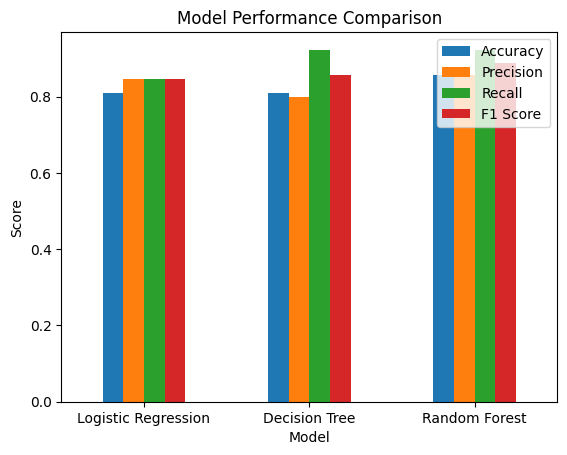

In [ ]:
plt.figure(figsize=(10,6))

results.set_index("Model").plot(
    kind="bar"
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
5,Activity_Count,0.331210
2,Assignment_Completion_Rate,0.181883
1,Assessment_Score,0.138721
4,Study_Hours,0.138226
0,Attendance_Percentage,0.113997
3,Login_Frequency,0.095963


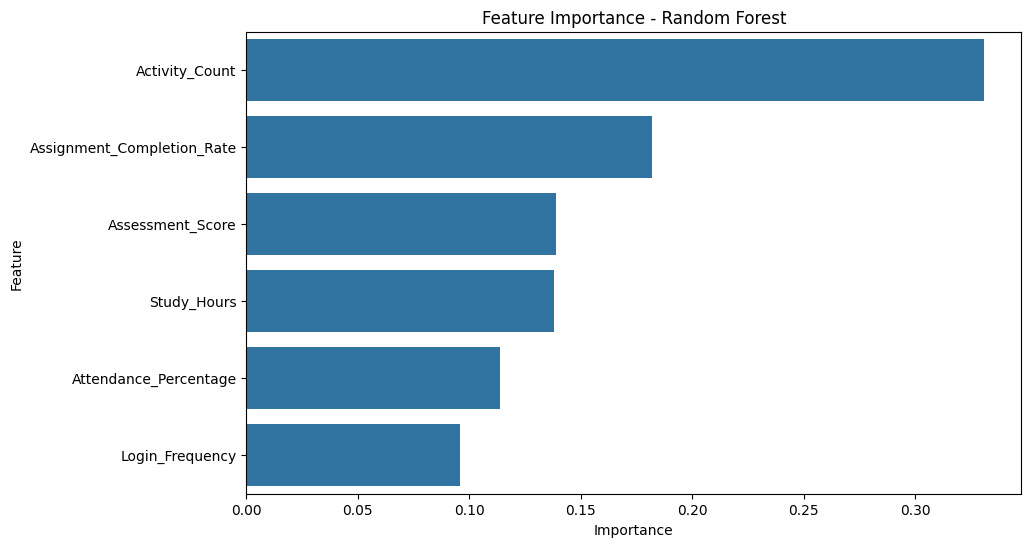

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title(
    "Feature Importance - Random Forest"
)
plt.show()